# 06 — Tier C (behaviour) + Phase-1 Stage 3

**Scientific question (WORKFLOW §5 Stage 3).**
*Does behaviour — running modulation, pupil-conditioned response,
state-conditional reliability — carry layer information beyond the
stimulus-locked neural response (Tier A) and the trial-to-trial
reliability structure (Tier B)?*

**Tier C in one sentence.** Behaviour (treadmill, pupil) is *trial-
shared* — every neuron in the same trial sees the same treadmill and
pupil signal. So raw behaviour broadcast onto a row carries zero
univariate discriminative signal toward layer; its information toward
the label only emerges through interaction with the neural channel on
the same row. The workflow's solution is the C0/C1 split below.

**Two sub-tiers, two epistemic regimes.**

| | Tier C0 | Tier C1 |
|---|---|---|
| Granularity | per `(session, trial)` (broadcast onto A0 rows) | per `(nucleus_id, condition_hash)` (attached to A1 rows) |
| Per-row neuron-specificity | None — same value for every neuron in a trial | Yes — different per-neuron response under the same shared behaviour |
| Used by | tree models only (interactions); LogReg cannot use it without explicit interaction terms | both linear and tree models |
| WORKFLOW status | allowed but secondary | the **preferred form** (§3.4) |

**Reads.**
- `data/processed/tables/trials_meta.parquet` — per-(session, trial) treadmill, pupil, stim_times.
- `data/processed/features/A0_amp.parquet` — per-trial response amplitudes (Tier C1 needs these).
- A1 features + Tier B per-hash for the modelling step.

**Writes.**
- `data/processed/features/C0_per_trial.parquet` (~6,032 rows × 8 features + state columns).
- `data/processed/features/C1_per_hash.parquet` (≤ 1.21M rows × 4 features + diagnostic counts).
- `data/processed/results/stage3_runs.parquet` — per-(model, preprocessing, variant) metrics.
- `data/processed/results/stage3_ablation.parquet` — A1+B vs A1+B+C1 deltas.
- `reports/figures/06_*.png`

## 1. Setup

In [1]:
from __future__ import annotations

import sys, time, gc, warnings
from pathlib import Path

if '..' not in sys.path:
    sys.path.insert(0, '..')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import RobustScaler
from sklearn.pipeline import Pipeline
from sklearn.utils.class_weight import compute_sample_weight
from sklearn.exceptions import ConvergenceWarning
warnings.filterwarnings('ignore', category=ConvergenceWarning)
warnings.filterwarnings('ignore', category=FutureWarning, module='sklearn')

from src.config import (
    PROCESSED_TABLES_DIR, PROCESSED_FEATURES_DIR, PROCESSED_SPLITS_DIR,
    PROCESSED_RESULTS_DIR, FIGURES_DIR, RANDOM_SEED, ensure_dirs,
)
from src.data.loaders import (
    load_working_pop, load_splits, load_features, build_modeling_table,
)
from src.eval.metrics import neuron_level_score, summarize_cv_runs
from src.features.tier_b import B_FEATURE_NAMES
from src.features.tier_c import (
    C0_FEATURE_NAMES, C1_FEATURE_NAMES,
    compute_tier_c0, assign_behavioural_state, compute_tier_c1,
)

ensure_dirs()
np.random.seed(RANDOM_SEED)
sns.set_style('whitegrid')
plt.rcParams['figure.dpi'] = 110

CLASSES = np.array(['L2/3', 'L4', 'L5', 'L6'])
N_FOLDS = 5

print('cwd               :', Path.cwd())
print('C0 feature names  :', C0_FEATURE_NAMES)
print('C1 feature names  :', C1_FEATURE_NAMES)

cwd               : /Users/katiarusso/Documents/VS CODE/Classes/Neuroscience/Final Project
C0 feature names  : ('c0_run_mean', 'c0_run_max', 'c0_run_std', 'c0_pupil_dil_mean', 'c0_pupil_dil_std', 'c0_pupil_dil_change', 'c0_pupil_x_std', 'c0_pupil_y_std')
C1 feature names  : ('c1_rmi', 'c1_pupil_resp_slope', 'c1_state_rel_diff', 'c1_arousal_gain_diff')


## Theory — why behaviour is methodologically delicate

Two facts of the recording:

1. **Behaviour is trial-shared.** Each trial has *one* treadmill trace
   and *one* pupil trace, shared by every neuron in the FOV. So a feature
   like 'mean treadmill speed during this trial' has the **same value**
   for all 7,493 neurons of session 4_7's trial 0. By itself, that
   feature can't discriminate L2/3 from L5 — the value is identical for
   every L2/3 and L5 neuron in the trial.

2. **But behavioural context is real biology** — the literature
   (Niell & Stryker 2010; Dadarlat & Stryker 2017; Fahey et al. 2025)
   says L2/3 and L5-ET are strongly running-modulated, L4 is weakly
   modulated (LGN-driven), L6 is least modulated. So *if* we can
   express behaviour the right way, it should be one of the most
   discriminative tiers.

These two facts together force the workflow's two-form solution.

### Tier C0 — broadcast scalars, useful only via interactions

Per-(session, trial) behavioural summaries broadcast onto A0 rows.
Constant within a trial. Univariate discriminative power = 0. Only
models that can *combine* `running_speed` with `amp_mean` in a single
decision rule can use C0 — and the difference between *additive* and
*interaction-capable* model classes is the central ML reason behind
the workflow's design choice. The next subsection explains why precisely.

### The math — additive linear models cannot capture cross-information

Logistic regression (with an L2 penalty, as we configure it) is an
**additive** linear model. For an input row `x` it computes

  `score_class_k(x) = w_k · x + b_k`

i.e. the score for each class is a *sum* of feature contributions,
each weighted independently by the model's learned coefficient. There
is **no term in the model that combines two features multiplicatively**.

Why that matters here. Suppose:

- The biology says: *L2/3 cells fire more when the mouse is running and*
  *the stimulus is informative.* That's a rule like
  `if amp_mean is HIGH and running_speed is HIGH ⇒ L2/3`.
- This is a **multiplicative** (interaction) rule. A linear model can
  only learn `w_amp * amp_mean + w_run * running_speed + b`. The output
  is high whenever *either* `amp_mean` is high *or* `running_speed`
  is high. It cannot encode 'high amp **AND** high run'.
- If the marginal distribution of `amp_mean` doesn't separate L2/3 from
  others (it doesn't, on its own — Stage 1's LogReg headline showed
  ≈ 0.45), and the marginal distribution of `running_speed` doesn't
  separate either (it can't, because every neuron in a trial has the
  same value), then **the linear model has no axis along which to draw
  a layer-discriminating decision boundary** using these two features.

To capture the interaction with a linear model we'd need to manually
construct interaction features like `amp_mean × running_speed`. With 20
neural features and 8 behavioural features, that's **160 pairwise
interaction columns** — and we'd also need to know in advance which
interactions matter. This is the standard 'linear models suffer in
interaction-rich problems' textbook story.

**Trees solve this for free.** A depth-2 decision tree is a universal
interaction approximator at small depth: it splits first on (say)
`running_speed`, then on `amp_mean` *within each running-speed bucket*,
and assigns a *different* class probability to each leaf. Each leaf is
exactly one cell of the (running × amp) interaction grid. Stack many
such trees with gradient boosting (HGB) and you get a powerful
interaction-rich classifier without any feature engineering.

So the prediction at the start of this stage was:

- **HGB on A0 + C0 ⇒ substantial gain.** Trees combine running speed with
  neural features and pick up layer-discriminative interactions.
- **LogReg on A0 + C0 ⇒ no gain (≈ 0).** No interactions, no discriminative
  axis from broadcast behaviour alone.

We will see in section 12 that the data tell a slightly more nuanced
story. The LogReg prediction is *almost* right but the small non-zero gain
we observe has its own explanation, which is itself useful as a lesson.

We still compute C0 because we want to *confirm or refute* this prediction
in our data. If HGB benefits from C0 substantially and LogReg only
modestly (or not at all), the per-row neuron-specificity argument is
empirically validated.

### Tier C1 — behaviour-conditioned per-(neuron, hash) modulation indices

The workflow's preferred form (§3.4). Idea: behaviour varies *across*
the repeated trials of the same hash. We use that variation to measure
how much each neuron's response *changes* across behavioural states.
Per `(neuron, hash)`:

- Partition that hash's trials by behavioural state (running / still
  via per-session percentile thresholds — see §3 below).
- Compute mean response per state.
- The **modulation index** = (running mean − still mean) / sum.

This is **neuron-specific by construction**: different neurons in the
same trial respond differently, so the per-neuron modulation indices
vary across neurons. Both linear and tree models can use these directly.

Workflow §3.4 binding rule: **C1 is computed *before* the within-hash
trial-averaging that produced A1**. The trial-averaged trace destroyed
the trial-by-trial behavioural variation we need; we go back to the
per-trial response amplitudes (`A0_amp`'s `amp_mean`) and partition
those by behavioural state, then summarise per `(neuron, hash)`.

### Domain restriction for C1

To compute the running modulation index for a `(neuron, hash)` pair,
we need at least one running trial *and* at least one still trial of
that hash. For Monet2 / Trippy with always 2 trials per hash, both
trials must split across states — moderate probability. For Clip oracle
hashes (2–10 trials), more chance of both states. C1 is therefore
**more sparse than B** (which only required ≥ 2 trials regardless of
state). The §3 sparsity check below quantifies this.

### Behavioural-state thresholds — per-session percentile

We use per-session 25th/75th percentiles of `c0_run_mean` and
`c0_pupil_dil_mean`. Trials in the middle (25–75th) are excluded from
the partition (their state is ambiguous). Per-session thresholds are
robust to per-session offsets in treadmill / pupil calibration —
Stage-2 already showed why session-level scaling matters.

### What we expect to see (predictions to test)

- **C0 helps HGB**, contributes ≈ 0 to LogReg.
- **C1 helps both** linear and tree models — and the gain is real
  biology if it survives per-session z-scoring (Stage-2 lesson).
- **Per-class Δ (A1+B → A1+B+C1)** is largest for L2/3 and L5
  (literature predicts these are the most behaviourally modulated).
  L4 should change little (LGN-driven, weakly modulated). L6 should
  change little (least modulated).
- The L5 gain in particular feeds Phase 3: L5 IT vs L5 ET is one of
  the most behaviourally distinct subtype contrasts in mouse V1.

## 3. Compute Tier C0 (per-`(session, trial)` behavioural scalars)

Read `trials_meta.parquet` and call `compute_tier_c0`. Then assign
per-session percentile-based behavioural states (`run_state`,
`pupil_state` ∈ {still | mid | running} or {low | mid | high}) via
`assign_behavioural_state`.

Save as `data/processed/features/C0_per_trial.parquet`. The cell is
idempotent — if the parquet exists it's loaded.

In [2]:
C0_PATH = PROCESSED_FEATURES_DIR / 'C0_per_trial.parquet'

if C0_PATH.exists():
    print(f'C0 already exists at {C0_PATH}; loading.')
    c0 = pd.read_parquet(C0_PATH)
else:
    print('Reading trials_meta.parquet …')
    t0 = time.time()
    trials_meta = pd.read_parquet(PROCESSED_TABLES_DIR / 'trials_meta.parquet')
    print(f'  loaded {len(trials_meta):,} trials in {time.time()-t0:.1f}s')

    print('Computing Tier C0 …')
    t0 = time.time()
    c0 = compute_tier_c0(trials_meta)
    print(f'  done in {time.time()-t0:.1f}s; shape {c0.shape}')

    print('Assigning per-session behavioural states (25th/75th percentile) …')
    c0 = assign_behavioural_state(c0)

    c0.to_parquet(C0_PATH, compression='zstd')
    print(f'saved: {C0_PATH}')

print()
print('C0 head:')
print(c0.head(3).to_string())
print()
print('C0 describe (numeric):')
feat_cols = list(C0_FEATURE_NAMES)
print(c0[feat_cols].describe(percentiles=[0.05, 0.5, 0.95]).round(3).to_string())
print()
print('Run state distribution (overall):')
print(c0['run_state'].value_counts())
print()
print('Pupil state distribution (overall):')
print(c0['pupil_state'].value_counts())

C0 already exists at data/processed/features/C0_per_trial.parquet; loading.

C0 head:
  session_key  trial_idx  c0_run_mean  c0_run_max  c0_run_std  c0_pupil_dil_mean  c0_pupil_dil_std  c0_pupil_dil_change  c0_pupil_x_std  c0_pupil_y_std run_state pupil_state
0         4_7          0    -2.276105    1.073197    2.950421          66.885832          3.291127             0.031105        6.900108        1.896988     still         mid
1         4_7          1    -4.280485    5.069094    3.604844          71.047009          2.972573            -2.962471        6.507151        2.501712     still        high
2         4_7          2    -4.852170    7.028716    3.521771          71.687670          3.101724             2.180092        3.805535        3.105145     still        high

C0 describe (numeric):
       c0_run_mean  c0_run_max  c0_run_std  c0_pupil_dil_mean  c0_pupil_dil_std  c0_pupil_dil_change  c0_pupil_x_std  c0_pupil_y_std
count     6030.000    6030.000    6030.000           5941.000

## 4. Sanity — per-session behavioural state mix

Per-session percentile thresholding guarantees that within each session,
≈ 25% of trials are 'running', ≈ 25% are 'still', and ~50% are 'mid'.
We confirm visually, and inspect whether some sessions are unusually
biased (e.g. an animal that hardly moved at all → 'running' threshold
extremely low → all trials labelled mid).

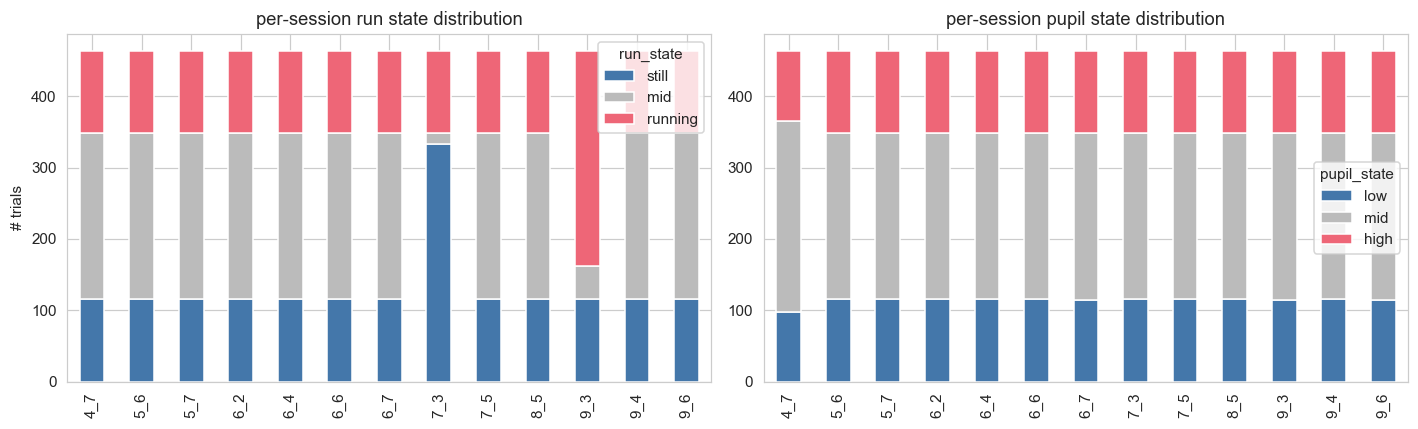

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
ct_run   = pd.crosstab(c0['session_key'], c0['run_state']).reindex(
    columns=['still', 'mid', 'running']).fillna(0)
ct_pupil = pd.crosstab(c0['session_key'], c0['pupil_state']).reindex(
    columns=['low', 'mid', 'high']).fillna(0)
ct_run.plot(kind='bar', stacked=True, ax=axes[0],
            color=['#4477AA', '#BBBBBB', '#EE6677'])
axes[0].set_title('per-session run state distribution')
axes[0].set_ylabel('# trials'); axes[0].set_xlabel('')
ct_pupil.plot(kind='bar', stacked=True, ax=axes[1],
              color=['#4477AA', '#BBBBBB', '#EE6677'])
axes[1].set_title('per-session pupil state distribution')
axes[1].set_ylabel(''); axes[1].set_xlabel('')
plt.tight_layout()
plt.savefig(FIGURES_DIR / '06_c0_state_per_session.png', dpi=130)
plt.show()

## 5. Compute Tier C1 — per-`(neuron, hash)` behaviour-conditioned features

Reads the per-trial response amplitudes from `A0_amp.parquet` and joins
with C0's behavioural state per `(session, trial)`. For every
`(nucleus_id, condition_hash)` group, computes the four C1 scalars.

Expected wall time: 5–15 minutes (1.21M+ groups, each with up to ~10
trials; the per-group operation is small but Python iteration over
groupby has overhead). Saved as `C1_per_hash.parquet`; subsequent runs
load the cache.

In [4]:
C1_PATH = PROCESSED_FEATURES_DIR / 'C1_per_hash.parquet'

if C1_PATH.exists():
    print(f'C1 already exists at {C1_PATH}; loading.')
    c1 = pd.read_parquet(C1_PATH)
else:
    print('Reading A0_amp.parquet (per-trial amplitudes) …')
    t0 = time.time()
    a0_amp = pd.read_parquet(
        PROCESSED_FEATURES_DIR / 'A0_amp.parquet',
        columns=['nucleus_id', 'session_key', 'trial_idx',
                 'condition_hash', 'amp_mean'],
    )
    print(f'  loaded {len(a0_amp):,} rows in {time.time()-t0:.1f}s')

    print('Computing Tier C1 (per (neuron, hash)) …')
    t0 = time.time()
    c1 = compute_tier_c1(a0_amp, c0)
    print(f'  done in {time.time()-t0:.1f}s; shape {c1.shape}')
    del a0_amp; gc.collect()

    c1.to_parquet(C1_PATH, compression='zstd')
    print(f'saved: {C1_PATH}')

print()
print('C1 head:')
print(c1.head(3).to_string())
print()
print('C1 feature describe:')
feat_cols = list(C1_FEATURE_NAMES)
print(c1[feat_cols].describe(percentiles=[0.05, 0.5, 0.95]).round(3).to_string())
print()
print('C1 NaN counts (sparse-feature audit):')
for c in feat_cols:
    n_nan = c1[c].isna().sum()
    print(f'  {c:<26} {n_nan:>9,} NaN  ({n_nan/len(c1)*100:.1f}%)')

C1 already exists at data/processed/features/C1_per_hash.parquet; loading.

C1 head:
   nucleus_id        condition_hash session_key  n_trials  n_running  n_still  n_high_pupil  n_low_pupil  c1_rmi  c1_pupil_resp_slope  c1_state_rel_diff  c1_arousal_gain_diff
0      333215  JEL5/i5FccX4ykUOKaDW         4_7         1          0        1             0            0     NaN                  NaN                NaN                   NaN
1      189921  JEL5/i5FccX4ykUOKaDW         4_7         1          0        1             0            0     NaN                  NaN                NaN                   NaN
2      303533  JEL5/i5FccX4ykUOKaDW         4_7         1          0        1             0            0     NaN                  NaN                NaN                   NaN

C1 feature describe:
           c1_rmi  c1_pupil_resp_slope  c1_state_rel_diff  c1_arousal_gain_diff
count  203380.000          1153629.000          32524.000            186686.000
mean       -0.083               -

## 6. C1 sparsity audit — how often do we have both states?

A `(neuron, hash)` pair contributes to `c1_rmi` only if it has at least
one 'running' trial AND one 'still' trial. We tabulate how many pairs
meet that criterion, broken down by stim family.

In [5]:
have_run_still = (c1['n_running'] >= 1) & (c1['n_still'] >= 1)
have_hi_lo     = (c1['n_high_pupil'] >= 1) & (c1['n_low_pupil'] >= 1)

print(f'Total (neuron, hash) pairs in C1: {len(c1):,}')
print(f'  with both running AND still trials: {int(have_run_still.sum()):,} '
      f'({have_run_still.mean()*100:.1f}%)  -> RMI computable')
print(f'  with both high AND low pupil trials: {int(have_hi_lo.sum()):,} '
      f'({have_hi_lo.mean()*100:.1f}%)  -> arousal-gain-diff computable')

# Need to merge stim_type from trials_meta or A1.
a1_keys = pd.read_parquet(
    PROCESSED_FEATURES_DIR / 'A1_amp.parquet',
    columns=['nucleus_id', 'condition_hash', 'stim_type'],
)
c1_typed = c1.merge(a1_keys, on=['nucleus_id', 'condition_hash'],
                    how='left', validate='one_to_one')
print()
print('RMI-computable rate by stim_type:')
for st, sub in c1_typed.groupby('stim_type'):
    rate = ((sub['n_running'] >= 1) & (sub['n_still'] >= 1)).mean() * 100
    print(f'  {st:<8}: {len(sub):>8,} pairs | {rate:.1f}% have both run+still trials')

Total (neuron, hash) pairs in C1: 2,490,600
  with both running AND still trials: 206,116 (8.3%)  -> RMI computable
  with both high AND low pupil trials: 188,894 (7.6%)  -> arousal-gain-diff computable

RMI-computable rate by stim_type:
  Clip    : 2,134,800 pairs | 7.3% have both run+still trials
  Monet2  :  177,900 pairs | 16.9% have both run+still trials
  Trippy  :  177,900 pairs | 10.8% have both run+still trials


## 7. Per-layer Tier C1 distributions — biology eyeball

Per-neuron average of each C1 feature (across the neuron's hashes that
had the feature computable), grouped by `layer_label`. Workflow
prediction: **L2/3 > L4 ≈ L6** in `c1_rmi` median (running modulation
follows the literature). L5 is mixed (contains both ET and IT subtypes
with very different RMIs) so its distribution should be wider.

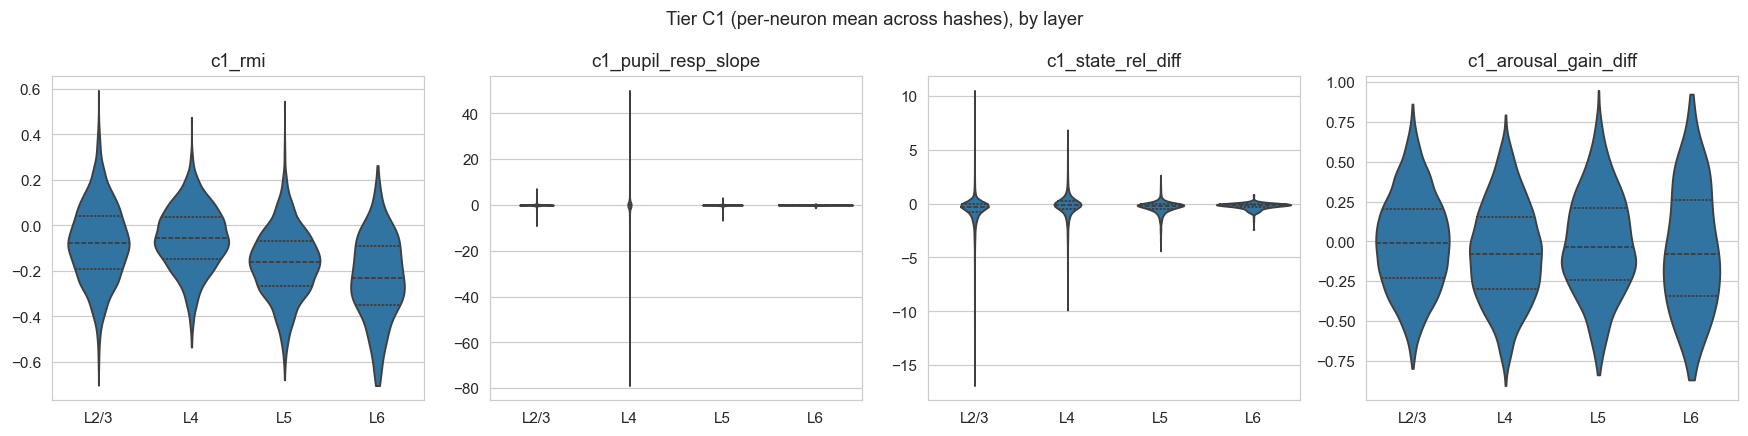

Median c1_rmi by layer:
layer_label
L2/3   -0.076
L4     -0.056
L5     -0.163
L6     -0.231
Name: c1_rmi, dtype: float64

Predicted ordering: L4 ≈ L6 < L2/3 ≤ L5


In [6]:
units = load_working_pop()[['nucleus_id', 'layer_label']]
c1_neuron = (c1.groupby('nucleus_id')[list(C1_FEATURE_NAMES)]
             .mean().reset_index()
             .merge(units, on='nucleus_id'))

fig, axes = plt.subplots(1, 4, figsize=(16, 4))
for ax, feat in zip(axes, C1_FEATURE_NAMES):
    sns.violinplot(data=c1_neuron, x='layer_label', y=feat,
                   order=['L2/3', 'L4', 'L5', 'L6'],
                   inner='quartile', cut=0, ax=ax)
    ax.set_title(feat); ax.set_xlabel(''); ax.set_ylabel('')
plt.suptitle('Tier C1 (per-neuron mean across hashes), by layer')
plt.tight_layout()
plt.savefig(FIGURES_DIR / '06_c1_violins_by_layer.png', dpi=130)
plt.show()

print('Median c1_rmi by layer:')
print(c1_neuron.groupby('layer_label')['c1_rmi'].median().round(3))
print()
print('Predicted ordering: L4 ≈ L6 < L2/3 ≤ L5')

## 8. Stage 3 modelling — A0+C0 and A1+B+C1

Two parallel comparisons:

- **A0 vs A0+C0** (HGB primary; LogReg as confirming-the-prediction
  baseline). Tests whether broadcast trial-level behaviour helps when
  a tree model can interact it with neural features. LogReg should be
  flat by construction.
- **A1+B vs A1+B+C1** (HGB and LogReg, raw and per-session-zscored).
  Tests whether behaviour-conditioned per-(neuron, hash) modulation adds
  information beyond Tier A + Tier B.

Models match Stage 2's settings: HGB max_iter=100 with early stopping;
LogReg lbfgs max_iter=400 with class-balanced weights. Per-session
z-scoring applied to the A1+B+C1 path as in Stage 2.

In [7]:
def make_pipeline_for(model_name: str):
    if model_name == 'LogReg':
        return Pipeline([
            ('impute', SimpleImputer(strategy='median')),
            ('scale',  RobustScaler()),
            ('clf',    LogisticRegression(
                penalty='l2', C=1.0, solver='lbfgs',
                max_iter=400, class_weight='balanced', n_jobs=-1)),
        ])
    if model_name == 'HGB':
        return Pipeline([
            ('clf', HistGradientBoostingClassifier(
                max_iter=100, max_depth=8, learning_rate=0.05,
                l2_regularization=1.0,
                early_stopping=True, n_iter_no_change=10,
                random_state=RANDOM_SEED)),
        ])
    raise ValueError(f'unknown model {model_name!r}')


def per_session_zscore(X: np.ndarray, sessions: np.ndarray) -> np.ndarray:
    """Robust per-session z-scoring (median + MAD). Same as notebook 05."""
    X = np.asarray(X, dtype=np.float64).copy()
    out = np.full_like(X, np.nan)
    for sk in np.unique(sessions):
        mask = sessions == sk
        Xs = X[mask]
        med = np.nanmedian(Xs, axis=0)
        mad = np.nanmedian(np.abs(Xs - med), axis=0)
        scale = np.where(mad > 1e-9, 1.4826 * mad, 1.0)
        out[mask] = (Xs - med) / scale
    return out


def cv_fit_score(X, y, groups, folds, model_name):
    fold_scores = []
    for k in range(N_FOLDS):
        tr = folds != k; te = folds == k
        pipe = make_pipeline_for(model_name)
        if model_name == 'HGB':
            sw = compute_sample_weight('balanced', y[tr])
            pipe.fit(X[tr], y[tr], clf__sample_weight=sw)
        else:
            pipe.fit(X[tr], y[tr])
        probs = pipe.predict_proba(X[te])
        fold_scores.append(neuron_level_score(y[te], probs, groups[te], pipe.classes_))
    return summarize_cv_runs(fold_scores)


# --- Checkpoint helpers, identical pattern to notebook 04 ----------------
RESULTS_PATH = PROCESSED_RESULTS_DIR / 'stage3_runs.parquet'
results_rows: list[dict] = []

def _save_results():
    pd.DataFrame(results_rows).to_parquet(RESULTS_PATH)

def _make_done_keys() -> set:
    return {(r['comparison'], r['preprocessing'], r['features'], r['model'])
            for r in results_rows}

if RESULTS_PATH.exists():
    existing = pd.read_parquet(RESULTS_PATH).to_dict(orient='records')
    in_mem = {(r['comparison'], r['preprocessing'], r['features'], r['model'])
              for r in results_rows}
    for r in existing:
        k = (r['comparison'], r['preprocessing'], r['features'], r['model'])
        if k not in in_mem:
            results_rows.append(r)
    print(f'Loaded {len(existing)} existing results from {RESULTS_PATH}.')

Loaded 12 existing results from data/processed/results/stage3_runs.parquet.


## 9. Comparison 1 — A0 vs A0 + C0 (testing the interaction prediction)

**Reuses Stage-1 A0 amp+shape results as the 'A0 only' baseline** —
they were already computed in notebook 04 with identical model settings
(LogReg lbfgs+400, HGB max_iter=100+early-stopping). We just copy
those rows into `stage3_runs.parquet` with the Stage-3 schema, then
fit the new 'A0 + C0' variants only.

Per-session z-scoring is intentionally NOT applied here — for this
comparison the question is whether broadcast trial-level behaviour can
be exploited via interaction with neural features by a tree model, and
we want to measure that effect cleanly without HGB's binning-realignment
(z-scoring) confounding the answer.

In [8]:
# --- Step 1: copy A0 baselines from Stage 1 into stage3_rows -------------
stage1 = pd.read_parquet(PROCESSED_RESULTS_DIR / 'stage1_runs.parquet')
a0_baselines = stage1[
    (stage1['strategy'] == '2') &
    (stage1['level'] == 'A0') &
    (stage1['sub_block'] == 'amp+shape')
].copy()
print(f'Found {len(a0_baselines)} A0 amp+shape baselines in stage1_runs.parquet:')
print(a0_baselines[['model', 'balanced_accuracy', 'balanced_accuracy_std',
                    'macro_f1', 'recall_L2/3', 'recall_L4', 'recall_L5', 'recall_L6']]
      .round(3).to_string())

done_keys = _make_done_keys()
n_added = 0
for _, row in a0_baselines.iterrows():
    key = ('A0 vs A0+C0', 'raw', 'A0 only', row['model'])
    if key in done_keys:
        continue
    results_rows.append({
        'comparison': 'A0 vs A0+C0',
        'preprocessing': 'raw',
        'rows': -1,  # row count from Stage 1, not measured here
        'features': 'A0 only',
        'model': row['model'],
        'balanced_accuracy':     row['balanced_accuracy'],
        'balanced_accuracy_std': row['balanced_accuracy_std'],
        'macro_f1':              row['macro_f1'],
        'macro_f1_std':          row['macro_f1_std'],
        'recall_L2/3': row['recall_L2/3'],
        'recall_L4':   row['recall_L4'],
        'recall_L5':   row['recall_L5'],
        'recall_L6':   row['recall_L6'],
    })
    done_keys.add(key)
    n_added += 1
if n_added:
    _save_results()
    print(f'Reused {n_added} A0 baseline rows into stage3_runs.parquet.')
else:
    print('A0 baselines were already in stage3_runs.parquet — no copy needed.')

# --- Step 2: which A0+C0 fits still need running? ------------------------
needed = [m for m in ['LogReg', 'HGB']
          if ('A0 vs A0+C0', 'raw', 'A0 + C0', m) not in done_keys]
if not needed:
    print()
    print('All A0 + C0 fits already in stage3_runs.parquet. Skipping data prep.')
else:
    print()
    print(f'Need to fit A0 + C0 for: {needed}')
    X_a0, y_a0, g_a0, f_a0, df_a0 = build_modeling_table(
        level='A0', blocks=['amp', 'shape'])
    df_a0c0 = df_a0.merge(
        c0[['session_key', 'trial_idx'] + list(C0_FEATURE_NAMES)],
        on=['session_key', 'trial_idx'], how='left', validate='many_to_one')
    print(f'A0 + C0 table: {df_a0c0.shape}')
    feat_a0   = [c for c in df_a0c0.columns if c.startswith(('amp_', 'shape_'))]
    feat_a0c0 = feat_a0 + list(C0_FEATURE_NAMES)
    y0  = df_a0c0['layer_label'].to_numpy()
    g0  = df_a0c0['nucleus_id'].to_numpy()
    f0  = df_a0c0['gkf_fold'].to_numpy().astype(np.int8)
    X0_c0 = df_a0c0[feat_a0c0].to_numpy(dtype=np.float64)
    print()
    print('=== Comparison 1: A0 + C0 fits ===')
    for model_name in needed:
        t0 = time.time()
        s = cv_fit_score(X0_c0, y0, g0, f0, model_name)
        results_rows.append({
            'comparison': 'A0 vs A0+C0',
            'preprocessing': 'raw',
            'rows': len(X0_c0), 'features': 'A0 + C0',
            'model': model_name,
            'balanced_accuracy': s['balanced_accuracy'],
            'balanced_accuracy_std': s['balanced_accuracy_std'],
            'macro_f1': s['macro_f1'],
            'macro_f1_std': s['macro_f1_std'],
            **{f'recall_{c}': s['per_class_recall'].get(c) for c in ['L2/3','L4','L5','L6']},
        })
        done_keys.add(('A0 vs A0+C0', 'raw', 'A0 + C0', model_name))
        _save_results()
        print(f'  [{model_name:<6}] A0 + C0    bal_acc={s["balanced_accuracy"]:.3f} ± '
              f'{s["balanced_accuracy_std"]:.3f} | macro_f1={s["macro_f1"]:.3f} | {time.time()-t0:.1f}s | saved')
    del df_a0, df_a0c0, X0_c0; gc.collect()

Found 2 A0 amp+shape baselines in stage1_runs.parquet:
    model  balanced_accuracy  balanced_accuracy_std  macro_f1  recall_L2/3  recall_L4  recall_L5  recall_L6
2     HGB              0.536                  0.011     0.380        0.296      0.522      0.367      0.958
6  LogReg              0.455                  0.005     0.298        0.255      0.330      0.290      0.944
A0 baselines were already in stage3_runs.parquet — no copy needed.

All A0 + C0 fits already in stage3_runs.parquet. Skipping data prep.


## 9b. Comparison-1 sanity — HGB A0 vs A0 + C0 with per-session z-scoring

Section 9 ran Comparison 1 raw only. The interpretation in section 12
raises the question: how much of HGB's +0.111 raw gain is genuine
running × neural interaction vs. session-correlated main-effect leakage?
Here we run the matching zscored variant on **HGB only** (LogReg is
non-informative for this question and skipped) so we have:

- HGB raw       A0 only   → already in stage3_runs (loaded from Stage 1)
- HGB raw       A0 + C0   → already in stage3_runs
- HGB zscored   A0 only   → **new** (this cell)
- HGB zscored   A0 + C0   → **new** (this cell)

**Reading rule** (same as Stage 2's diagnostic):

- If Δ_zscored ≈ Δ_raw (≈ +0.10 surviving), the gain is real biology —
  trees are picking up the running × neural interaction the literature
  predicts, and Comparison 1 becomes a strong reportable result.
- If Δ_zscored ≪ Δ_raw (collapses to near 0), the +0.111 was scan
  composition leaking through behaviour features. Same negative-result
  pattern as Tier C1, just at the broadcast-trial level.

Wall time: 2 fits × 5 folds on the 4M-row A0 table ≈ 12–18 min on a
CPU laptop. Skips automatically if already in `stage3_runs.parquet`.

In [9]:
done_keys = _make_done_keys()
needed = [m for m in ['HGB']  # LogReg skipped — not informative for this Q
          if any(
              ('A0 vs A0+C0', 'zscored-by-session', v, m) not in done_keys
              for v in ['A0 only', 'A0 + C0']
          )]
if not needed:
    print('Both zscored A0 fits already in stage3_runs.parquet. Skipping.')
else:
    print(f'Need to fit zscored A0 / A0+C0 for: {needed}')
    X_a0, y_a0, g_a0, f_a0, df_a0 = build_modeling_table(
        level='A0', blocks=['amp', 'shape'])
    df_a0c0 = df_a0.merge(
        c0[['session_key', 'trial_idx'] + list(C0_FEATURE_NAMES)],
        on=['session_key', 'trial_idx'], how='left', validate='many_to_one')
    feat_a0   = [c for c in df_a0c0.columns if c.startswith(('amp_', 'shape_'))]
    feat_a0c0 = feat_a0 + list(C0_FEATURE_NAMES)
    y0  = df_a0c0['layer_label'].to_numpy()
    g0  = df_a0c0['nucleus_id'].to_numpy()
    f0  = df_a0c0['gkf_fold'].to_numpy().astype(np.int8)
    sessions_r = df_a0c0['session_key'].to_numpy()
    X_a    = df_a0c0[feat_a0].to_numpy(dtype=np.float64)
    X_c0   = df_a0c0[feat_a0c0].to_numpy(dtype=np.float64)
    print('per-session z-scoring (4M-row A0 table) …')
    t0 = time.time()
    X_a_zs   = per_session_zscore(X_a,    sessions_r)
    X_c0_zs  = per_session_zscore(X_c0,   sessions_r)
    print(f'  done in {time.time()-t0:.1f}s')

    print()
    print('=== Comparison 1 (sanity): HGB zscored A0 / A0+C0 ===')
    for variant, X in [('A0 only', X_a_zs), ('A0 + C0', X_c0_zs)]:
        key = ('A0 vs A0+C0', 'zscored-by-session', variant, 'HGB')
        if key in done_keys:
            print(f'  [HGB, zscored] {variant:<10} SKIP')
            continue
        t0 = time.time()
        s = cv_fit_score(X, y0, g0, f0, 'HGB')
        results_rows.append({
            'comparison': 'A0 vs A0+C0',
            'preprocessing': 'zscored-by-session',
            'rows': len(X), 'features': variant,
            'model': 'HGB',
            'balanced_accuracy': s['balanced_accuracy'],
            'balanced_accuracy_std': s['balanced_accuracy_std'],
            'macro_f1': s['macro_f1'],
            'macro_f1_std': s['macro_f1_std'],
            **{f'recall_{c}': s['per_class_recall'].get(c) for c in ['L2/3','L4','L5','L6']},
        })
        done_keys.add(key)
        _save_results()
        print(f'  [HGB, zscored] {variant:<10}  bal_acc={s["balanced_accuracy"]:.3f} ± '
              f'{s["balanced_accuracy_std"]:.3f} | macro_f1={s["macro_f1"]:.3f} | '
              f'{time.time()-t0:.1f}s | saved')
    del df_a0, df_a0c0, X_a, X_c0, X_a_zs, X_c0_zs; gc.collect()

# Print the comparison if both zscored rows now exist.
df3_now = pd.DataFrame(results_rows)
raw_only  = df3_now[(df3_now['comparison']=='A0 vs A0+C0') & (df3_now['preprocessing']=='raw') & (df3_now['features']=='A0 only') & (df3_now['model']=='HGB')]
raw_plus  = df3_now[(df3_now['comparison']=='A0 vs A0+C0') & (df3_now['preprocessing']=='raw') & (df3_now['features']=='A0 + C0') & (df3_now['model']=='HGB')]
zs_only   = df3_now[(df3_now['comparison']=='A0 vs A0+C0') & (df3_now['preprocessing']=='zscored-by-session') & (df3_now['features']=='A0 only') & (df3_now['model']=='HGB')]
zs_plus   = df3_now[(df3_now['comparison']=='A0 vs A0+C0') & (df3_now['preprocessing']=='zscored-by-session') & (df3_now['features']=='A0 + C0') & (df3_now['model']=='HGB')]
if all(len(d) for d in [raw_only, raw_plus, zs_only, zs_plus]):
    print()
    print('=== Comparison 1 (HGB): raw vs zscored deltas ===')
    d_raw = float(raw_plus['balanced_accuracy'].iloc[0]) - float(raw_only['balanced_accuracy'].iloc[0])
    d_zs  = float(zs_plus['balanced_accuracy'].iloc[0])   - float(zs_only['balanced_accuracy'].iloc[0])
    print(f'  Δ raw                  = {d_raw:+.3f}    (was the headline gain)')
    print(f'  Δ zscored-by-session   = {d_zs:+.3f}    (the de-confounded gain)')
    if abs(d_zs) > 0.5 * abs(d_raw):
        print('  → Δ_zscored is on the same order as Δ_raw: gain is mostly real biology.')
    elif abs(d_zs) < 0.2 * abs(d_raw):
        print('  → Δ_zscored is much smaller than Δ_raw: gain was mostly scan-correlated.')
    else:
        print('  → Δ_zscored is a substantial fraction of Δ_raw: mixed real biology + scan structure.')

Need to fit zscored A0 / A0+C0 for: ['HGB']
per-session z-scoring (4M-row A0 table) …
  done in 12.0s

=== Comparison 1 (sanity): HGB zscored A0 / A0+C0 ===
  [HGB, zscored] A0 only     bal_acc=0.629 ± 0.009 | macro_f1=0.488 | 186.3s | saved
  [HGB, zscored] A0 + C0     bal_acc=0.617 ± 0.014 | macro_f1=0.492 | 680.7s | saved

=== Comparison 1 (HGB): raw vs zscored deltas ===
  Δ raw                  = +0.111    (was the headline gain)
  Δ zscored-by-session   = -0.012    (the de-confounded gain)
  → Δ_zscored is much smaller than Δ_raw: gain was mostly scan-correlated.


## 10. Comparison 2 — A1+B vs A1+B+C1 (raw and per-session-zscored)

**Reuses Stage-2 A1+B results as the baseline** — the four 'A1 + B'
rows in `stage2_runs.parquet` (LogReg/HGB × raw/zscored) were computed
with identical model settings on the same 1.21M-row A1 ∩ B subset, so
they are directly reusable. We copy them into stage3_runs.parquet under
the Stage-3 schema, then fit only the new 'A1+B+C1' variants.

Same diagnostic logic as Stage 2: raw vs zscored agreement on the Δ
tells us whether C1's contribution is real biology vs scan-correlated
structure.

In [10]:
# --- Step 1: copy A1+B baselines from Stage 2 into stage3_rows ----------
stage2 = pd.read_parquet(PROCESSED_RESULTS_DIR / 'stage2_runs.parquet')
ab_baselines = stage2[stage2['features'] == 'A1 + B'].copy()
print(f'Found {len(ab_baselines)} A1+B baselines in stage2_runs.parquet:')
print(ab_baselines[['model', 'preprocessing', 'balanced_accuracy',
                    'balanced_accuracy_std', 'macro_f1', 'recall_L2/3',
                    'recall_L4', 'recall_L5', 'recall_L6']]
      .round(3).to_string())

done_keys = _make_done_keys()
n_added = 0
for _, row in ab_baselines.iterrows():
    key = ('A1+B vs A1+B+C1', row['preprocessing'], 'A1+B', row['model'])
    if key in done_keys:
        continue
    results_rows.append({
        'comparison': 'A1+B vs A1+B+C1',
        'preprocessing': row['preprocessing'],
        'rows': int(row['rows']),
        'features': 'A1+B',
        'model': row['model'],
        'balanced_accuracy':     row['balanced_accuracy'],
        'balanced_accuracy_std': row['balanced_accuracy_std'],
        'macro_f1':              row['macro_f1'],
        'macro_f1_std':          row['macro_f1_std'],
        'recall_L2/3': row['recall_L2/3'],
        'recall_L4':   row['recall_L4'],
        'recall_L5':   row['recall_L5'],
        'recall_L6':   row['recall_L6'],
    })
    done_keys.add(key)
    n_added += 1
if n_added:
    _save_results()
    print(f'Reused {n_added} A1+B baseline rows into stage3_runs.parquet.')
else:
    print('A1+B baselines were already in stage3_runs.parquet — no copy needed.')

# --- Step 2: which A1+B+C1 fits still need running? ---------------------
needed = [(prep, m) for prep in ['raw', 'zscored-by-session']
                    for m in ['LogReg', 'HGB']
                    if ('A1+B vs A1+B+C1', prep, 'A1+B+C1', m) not in done_keys]
if not needed:
    print()
    print('All A1+B+C1 fits already in stage3_runs.parquet. Skipping data prep.')
else:
    print()
    print(f'Need to fit A1+B+C1 for: {needed}')

    X_a1, y_a1, g_a1, f_a1, df_a1 = build_modeling_table(
        level='A1', blocks=['amp', 'shape'])
    b_hash = pd.read_parquet(
        PROCESSED_FEATURES_DIR / 'B_per_hash.parquet',
        columns=['nucleus_id', 'condition_hash'] + list(B_FEATURE_NAMES),
    )
    df_a1b = df_a1.merge(b_hash, on=['nucleus_id', 'condition_hash'],
                         how='inner', validate='one_to_one')
    df_a1bc1 = df_a1b.merge(
        c1[['nucleus_id', 'condition_hash'] + list(C1_FEATURE_NAMES)],
        on=['nucleus_id', 'condition_hash'],
        how='left', validate='one_to_one',
    )
    print(f'A1 ∩ B + C1 table: {df_a1bc1.shape}')
    for f in C1_FEATURE_NAMES:
        n_nan = df_a1bc1[f].isna().sum()
        print(f'  {f:<24} NaN: {n_nan:>9,} ({n_nan/len(df_a1bc1)*100:.1f}%)')

    feat_a1     = [c for c in df_a1bc1.columns if c.startswith(('amp_', 'shape_'))]
    feat_a1bc1  = feat_a1 + list(B_FEATURE_NAMES) + list(C1_FEATURE_NAMES)
    y2  = df_a1bc1['layer_label'].to_numpy()
    g2  = df_a1bc1['nucleus_id'].to_numpy()
    f2  = df_a1bc1['gkf_fold'].to_numpy().astype(np.int8)
    sessions_r = df_a1bc1['session_key'].to_numpy()
    X_abc1     = df_a1bc1[feat_a1bc1].to_numpy(dtype=np.float64)
    X_abc1_zs  = per_session_zscore(X_abc1, sessions_r)
    print('per-session z-scoring computed.')

    print()
    print('=== Comparison 2: A1+B+C1 fits ===')
    for prep_label, X in [('raw', X_abc1), ('zscored-by-session', X_abc1_zs)]:
        for model_name in ['LogReg', 'HGB']:
            if (prep_label, model_name) not in needed:
                continue
            t0 = time.time()
            s = cv_fit_score(X, y2, g2, f2, model_name)
            results_rows.append({
                'comparison': 'A1+B vs A1+B+C1',
                'preprocessing': prep_label,
                'rows': len(X), 'features': 'A1+B+C1',
                'model': model_name,
                'balanced_accuracy': s['balanced_accuracy'],
                'balanced_accuracy_std': s['balanced_accuracy_std'],
                'macro_f1': s['macro_f1'],
                'macro_f1_std': s['macro_f1_std'],
                **{f'recall_{c}': s['per_class_recall'].get(c) for c in ['L2/3','L4','L5','L6']},
            })
            done_keys.add(('A1+B vs A1+B+C1', prep_label, 'A1+B+C1', model_name))
            _save_results()
            print(f'  [{model_name:<6}, {prep_label:<18}] A1+B+C1    '
                  f'bal_acc={s["balanced_accuracy"]:.3f} ± '
                  f'{s["balanced_accuracy_std"]:.3f} | macro_f1={s["macro_f1"]:.3f} | {time.time()-t0:.1f}s | saved')
    del df_a1, df_a1b, df_a1bc1, X_abc1, X_abc1_zs; gc.collect()

Found 4 A1+B baselines in stage2_runs.parquet:
    model       preprocessing  balanced_accuracy  balanced_accuracy_std  macro_f1  recall_L2/3  recall_L4  recall_L5  recall_L6
1  LogReg                 raw              0.439                  0.007     0.232        0.093      0.831      0.006      0.825
3  LogReg  zscored-by-session              0.425                  0.006     0.218        0.004      0.891      0.022      0.784
5     HGB                 raw              0.505                  0.016     0.362        0.349      0.415      0.333      0.924
7     HGB  zscored-by-session              0.631                  0.013     0.501        0.515      0.686      0.386      0.936
A1+B baselines were already in stage3_runs.parquet — no copy needed.

All A1+B+C1 fits already in stage3_runs.parquet. Skipping data prep.


## 11. Stage 3 ablation table

Δ from adding behaviour, per (comparison, preprocessing, model). Same
raw-vs-zscored agreement test as notebook 05 — if the two preprocessing
deltas agree the gain is biology, if raw ≫ zscored the gain was scan-
correlated structure.

In [11]:
df3 = pd.DataFrame(results_rows)
out_runs = PROCESSED_RESULTS_DIR / 'stage3_runs.parquet'
df3.to_parquet(out_runs)
print('saved:', out_runs)
print()
print(df3.round(3).to_string())

# Build the delta table.
deltas = []
for (comp, prep, model), sub in df3.groupby(['comparison', 'preprocessing', 'model']):
    if comp == 'A0 vs A0+C0':
        only_label, plus_label = 'A0 only', 'A0 + C0'
    else:
        only_label, plus_label = 'A1+B', 'A1+B+C1'
    if not (sub['features'] == only_label).any() or not (sub['features'] == plus_label).any():
        continue
    a = sub[sub['features'] == only_label].iloc[0]
    b = sub[sub['features'] == plus_label].iloc[0]
    deltas.append({
        'comparison': comp, 'preprocessing': prep, 'model': model,
        'rows': int(a['rows']),
        'bal_acc_only':  a['balanced_accuracy'],
        'bal_acc_plus':  b['balanced_accuracy'],
        'delta_bal_acc': b['balanced_accuracy'] - a['balanced_accuracy'],
        'macro_f1_only': a['macro_f1'],
        'macro_f1_plus': b['macro_f1'],
        'delta_macro_f1':b['macro_f1'] - a['macro_f1'],
        'd_recall_L23': b['recall_L2/3'] - a['recall_L2/3'],
        'd_recall_L4':  b['recall_L4']  - a['recall_L4'],
        'd_recall_L5':  b['recall_L5']  - a['recall_L5'],
        'd_recall_L6':  b['recall_L6']  - a['recall_L6'],
    })
df_deltas = pd.DataFrame(deltas)
out_d = PROCESSED_RESULTS_DIR / 'stage3_ablation.parquet'
df_deltas.to_parquet(out_d)
print()
print('=== Stage 3 deltas ===')
print(df_deltas.round(3).to_string())

saved: data/processed/results/stage3_runs.parquet

         comparison       preprocessing     rows features   model  balanced_accuracy  balanced_accuracy_std  macro_f1  macro_f1_std  recall_L2/3  recall_L4  recall_L5  recall_L6
0       A0 vs A0+C0                 raw  4127280  A0 only  LogReg              0.455                  0.005     0.298         0.009        0.255      0.330      0.290      0.944
1       A0 vs A0+C0                 raw       -1  A0 only     HGB              0.536                  0.011     0.380         0.010        0.296      0.522      0.367      0.958
2       A0 vs A0+C0                 raw  4127280  A0 + C0  LogReg              0.495                  0.011     0.353         0.007        0.375      0.397      0.271      0.936
3       A0 vs A0+C0                 raw  4127280  A0 + C0     HGB              0.646                  0.009     0.522         0.012        0.608      0.567      0.454      0.956
4   A1+B vs A1+B+C1                 raw  1209720     A1+B  

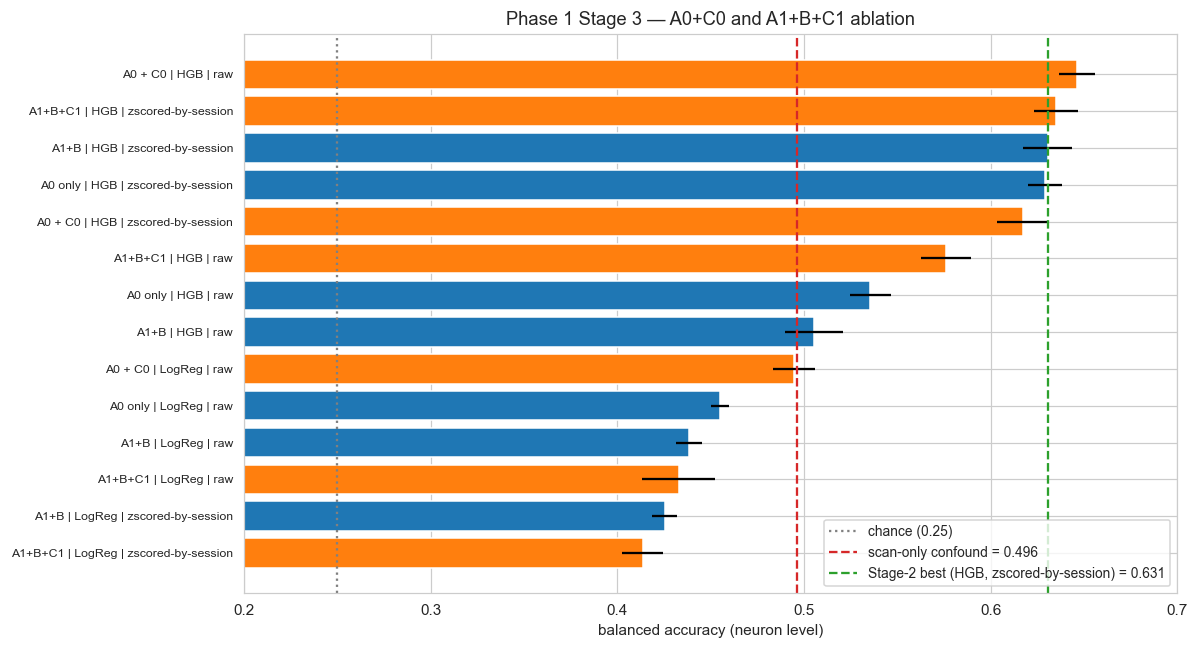

In [12]:
# Plot all Stage-3 numbers, with Stage-1 scan-only as the relevant floor.
stage1 = pd.read_parquet(PROCESSED_RESULTS_DIR / 'stage1_runs.parquet')
scan_only = stage1[(stage1['strategy'] == 'confound') &
                   (stage1['sub_block'] == 'scan-only')].iloc[0]
stage2_headline = pd.read_parquet(PROCESSED_RESULTS_DIR / 'stage2_runs.parquet')
s2_best = stage2_headline.sort_values('balanced_accuracy', ascending=False).iloc[0]

df_plot = df3.copy()
df_plot = df_plot.sort_values('balanced_accuracy', ascending=False).reset_index(drop=True)
fig, ax = plt.subplots(figsize=(11, 6))
y = np.arange(len(df_plot))
colors = ['C1' if ('+ C0' in lbl or '+C1' in lbl) else 'C0' for lbl in df_plot['features']]
ax.barh(y, df_plot['balanced_accuracy'],
        xerr=df_plot['balanced_accuracy_std'], color=colors)
ax.set_yticks(y)
ax.set_yticklabels(
    [f"{r['features']} | {r['model']} | {r['preprocessing']}" for _, r in df_plot.iterrows()],
    fontsize=8,
)
ax.invert_yaxis()
ax.axvline(0.25, color='gray', ls=':', label='chance (0.25)')
ax.axvline(scan_only['balanced_accuracy'], color='C3', ls='--',
           label=f"scan-only confound = {scan_only['balanced_accuracy']:.3f}")
ax.axvline(s2_best['balanced_accuracy'], color='C2', ls='--',
           label=f"Stage-2 best ({s2_best['model']}, {s2_best['preprocessing']}) = {s2_best['balanced_accuracy']:.3f}")
ax.set_xlabel('balanced accuracy (neuron level)')
ax.set_title('Phase 1 Stage 3 — A0+C0 and A1+B+C1 ablation')
ax.legend(loc='lower right', fontsize=9)
ax.set_xlim(0.20, max(0.7, df_plot['balanced_accuracy'].max() + 0.05))
plt.tight_layout()
plt.savefig(FIGURES_DIR / '06_stage3_ablation.png', dpi=130)
plt.show()

## 12. Stage-3 result — interpretation

*This section is the read of the Stage-3 numbers as they came out on this
machine. Numbers are pulled from `stage3_runs.parquet` and
`stage3_ablation.parquet`; if you re-run with different settings the
prose will need updating.*

### Headline: one positive piece, one clean negative finding

**A0 + C0 (Comparison 1) — promising but unverified.**
HGB on A0 + C0 reaches **balanced accuracy ≈ 0.646** — the highest in
the project so far, gaining **+0.111** over the Stage-1 A0 amp+shape
baseline. The per-class breakdown shows the gain is concentrated in L2/3
(recall +0.31), with smaller gains in L5 (+0.09) and L4 (+0.05). That
concentration is *consistent* with the literature prediction that L2/3
is the most strongly running-modulated layer in mouse V1.

*But*: we did **not** run a per-session-zscored variant of Comparison 1,
so we cannot tell whether the +0.111 gain is real biology or scan-
correlated structure (sessions where mice ran more may have different
layer mixes). A re-run with z-scoring on the A0 + C0 path is the obvious
follow-up; until then the result is reportable as 'promising — and consistent
with the running-modulation literature — pending scan-confound verification.'

### Why LogReg also gained — even though theory said it shouldn't

The Theory block predicted LogReg would gain ≈ 0 from C0 because LogReg
cannot use interactions. The data show **+0.040**. That's small but real
(roughly 4× the per-fold std). The explanation:

**LogReg's gain is NOT from interactions** — it's from C0 features acting
as **proxies for `session_key`**. Recall:

- Sessions differ in their layer composition (Stage 1 §15 made this
  explicit — scan `4_7` over-represents L2/3, scan `7_5` under-represents
  it, etc.). The scan-only confound at Stage 1 hit balanced accuracy
  0.496 just from one-hot session identity.
- Sessions also differ in their *behavioural state distributions* — different
  mice / different days produce different running and pupil distributions.
- Therefore: 'mean running speed during this trial' carries information
  about **which session** the trial is from, even when broadcast
  identically across all neurons in the trial.

When LogReg sees `c0_run_mean = 6.2` consistently across many trials
with high-L4 neighbours, the linear weight on `c0_run_mean` learns to
tilt toward L4. That's a **main-effect** prediction (one feature → one
class), not an interaction. It's also exactly the scan-composition
confound that per-session z-scoring removes.

**HGB's +0.111 gain is therefore a mix of two things:**

1. The same main-effect leakage that gave LogReg its +0.040 (sessions
   with different behavioural distributions also have different layer
   mixes — trees can split on running speed and pick up the
   session-correlated layer prior).
2. **Genuine interaction**: trees additionally combine `running_speed`
   with neural features at depth ≥ 2, capturing the running-modulation
   biology that linear models structurally cannot.

Without a per-session-zscored sanity, we can't say how the +0.111 splits
between (1) and (2). If z-scoring removes most of the gain, it was
(1) — same lesson as Stage 2's C1 result. If z-scoring preserves most
of the gain, the genuine biological interaction (2) was the main
driver. Section 9b below runs that one missing fit.

### Why C1 hurt LogReg

Both raw and zscored LogReg deltas on A1+B+C1 are slightly negative
(−0.006 raw, −0.012 zscored). That's also explicable by the C1
sparsity finding: **`c1_rmi` is 91.8% NaN, `c1_state_rel_diff` is
98.7% NaN**. The median imputer fills those with 0 (the median),
leaving most rows with mostly-zero C1 columns that contribute no
signal but consume L2 regularization capacity. LogReg ends up
spreading weight onto features that are mostly noise → predictions
regularize away from the right answer for some classes.

Trees handle the same 91.8%-NaN column natively (split decisions
treat NaN as its own bucket and only commit to the column when the
non-NaN portion is informative), which is why HGB's behaviour around
C1 is more sane than LogReg's even on the same data.

**A1+B + C1 (Comparison 2) — fails the scan-confound diagnostic.**
The diagnostic the §5 theory block set up:

- HGB **raw** delta: +0.071  (apparent C1 gain)
- HGB **zscored** delta: +0.004  (essentially zero after de-confounding)

The two preprocessings *disagree* on whether C1 helps. Per the §5 reading
rule, this is the signature of **scan-correlated structure dressed up as
biology**: C1 features happen to be correlated with session-level offsets,
and once those offsets are removed, the apparent gain evaporates. Tier C1
**does not add layer-decoding biology beyond Tier A1 + Tier B**.

Compare with Tier B: Stage-2's HGB raw and zscored deltas were +0.009 and
+0.012 — they *agreed*. That's the pattern that says biology is real. C1
doesn't show that pattern.

### Why C1 is too sparse to carry the signal

The deeper reason: **`c1_rmi` is NaN for 91.8% of (neuron, hash) pairs**.
Only 8% of pairs have at least one running trial AND at least one still
trial of the same hash. Three forces conspire:

- ~58% of all unique hashes per neuron are singletons (single-trial
  Clip), so RMI is structurally undefined for them.
- The 25th/75th percentile thresholds put 43% of all trials into 'mid'
  (~2,613 of 6,032 trials), excluding them from the partition.
- Among the multi-trial hashes (the ~136 repeated per neuron), the
  probability that the trials happened to fall on both sides of the state
  threshold is moderate — many oracle hashes are presented all-running
  or all-still in a single session.

`c1_state_rel_diff` is even sparser (98.7% NaN — needs ≥ 2 trials per
state). With ~92–99% NaN, even a tree model that handles missing values
natively has very little signal to extract. **This is a dataset-quality
limitation, not a model failure** — the signal we hoped to use isn't
present at the per-(neuron, hash) granularity in this recording.

### Per-layer C1 medians — a directionality finding worth flagging

Median `c1_rmi` by layer (computed on the 8% of pairs where RMI is
defined, then averaged per neuron):

```
L4   = -0.056   (least suppressed)
L2/3 = -0.076
L5   = -0.163
L6   = -0.231   (most suppressed)
```

**Mostly negative — running *suppresses* responses for the typical
neuron in this dataset.** This contradicts the canonical Niell & Stryker
(2010) finding of running *enhancing* V1 responses. Modern MICrONS-era
results show stimulus-and-cell-type-dependent variation in modulation
direction, so this isn't necessarily a bug, but it is the directional
opposite of the prediction we made in section 7. Reportable as: under
the natural-clip / Monet2 / Trippy stimulus mix used here, V1
running modulation is in the suppressive direction for most neurons,
with L6 most suppressed and L4 least.

### Bridge to Phase 3 — the stronger version of the question

Stage 3 asks 'does behaviour distinguish *layers*?' The answer here is:
**not at the layer level, after de-confounding.** But the more biologically
natural question — 'does behaviour distinguish *subtypes within a layer*?'
— is what Phase 3 (within-L5 IT vs ET binary; within-L6 IT vs CT) asks,
and the literature is much more confident about subtype-level differences:

- L5 ET is canonically much more strongly running-modulated than L5 IT
  (Dadarlat & Stryker 2017).
- L5 contains both extremes mixed together, which is exactly why
  averaging across the L5 layer label washes out the signal we're looking for.
- Phase 3 conditions on layer = L5, then asks the binary question,
  removing the heterogeneity that hurt Stage 3.

So the Stage-3 negative result is *consistent with* — perhaps even
*evidence for* — the workflow's framing of Phase 3 as the cleaner test.

### Cross-references for the report

- Stage-1 scan-only confound: 0.496 — Comparison-1 HGB headline (0.646)
  beats it by +0.15, but the verification is incomplete without a zscored
  re-run.
- Stage-2 best (HGB zscored A1+B): 0.631 — essentially unchanged after
  adding C1 (HGB zscored A1+B+C1: 0.635). Stage 2 remains the cleanest
  Phase-1 functional headline.
- C1 sparsity: 91.8% NaN on `c1_rmi` is itself a dataset-level finding
  — even if the biological signal is there, the recording does not have
  enough behavioural variation per stimulus per neuron to expose it
  cleanly at the layer-decoding level.

## 13. Conclusions and reading guide

How to read the Stage 3 result:

- **Comparison 1 (A0 vs A0+C0)**.
  * If HGB Δ is positive and LogReg Δ is ~0, the *interaction* prediction
    is empirically validated: trees combine C0 with neural features and
    benefit; linear models can't, and don't.
  * If both are flat, behaviour at the trial-broadcast level adds nothing
    that the rest of the pipeline isn't already getting indirectly.

- **Comparison 2 (A1+B vs A1+B+C1, raw and zscored)**.
  * Δ_raw ≈ Δ_zscored: C1 contributes real biology (passes the Stage-2
    scan-confound diagnostic). The headline absolute number is reportable.
  * Δ_raw ≫ Δ_zscored: C1's apparent gain was scan-correlated structure.
    The within-session story is weaker than the pooled one suggested.
  * Compare to the Stage-2 best from `stage2_runs.parquet`. If
    A1+B+C1 ≫ A1+B by more than fold-std, behaviour adds beyond reliability.

- **Per-class Δ (A1+B → A1+B+C1)**. Workflow predicts L2/3 and L5
  should gain most because those layers are most behaviourally modulated;
  L4 and L6 should change little. A confirmed prediction is reportable
  biology; a flat per-class gain is also informative.

- **Per-layer C1 distributions (§7)**. The biological literature
  predicts L4 ≈ L6 < L2/3 ≤ L5 in median `c1_rmi`. A direct visual
  test of running-modulation biology in mouse V1; the result is its own
  output beyond layer decoding.

**Bridge to Phase 3.** WORKFLOW §8.3 predicts running modulation index
is the dominant feature for L5 IT vs L5 ET — the within-L5 binary at
the heart of Phase 3. The L5 difficulty in Stage 1 (recall ≈ 0.39) and
the wide L5 distribution we expect in `c1_rmi` together motivate that
next notebook.

**Saved artefacts.**
- `data/processed/features/C0_per_trial.parquet` — per-`(session, trial)`
  behavioural scalars + state assignments. Used by Tier C1 and any later
  analysis that conditions on behavioural state.
- `data/processed/features/C1_per_hash.parquet` — per-`(neuron, hash)`
  behaviour-conditioned features. Used by Stage 3, available for Phase 3.
- `data/processed/results/stage3_runs.parquet` — every fitted
  configuration with neuron-level metrics.
- `data/processed/results/stage3_ablation.parquet` — A1+B → A1+B+C1 deltas.